<a href="https://colab.research.google.com/github/hongxu-yn/Southeast-Asia-XCO2-STK/blob/main/src/2_STK_Reconstruction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Initialization

In [ ]:
from google.colab import drive
import os
import shutil
from pathlib import Path
!pip install -q netCDF4 joblib tqdm xarray pykrige gstools cartopy scipy


drive.mount('/content/drive')
print("✅ Drive mounted successfully and environment initialization complete!")


SEA_EXTENT = [87, 148, -16, 33]
PROJECT_DIR=Path("/content/drive/MyDrive/Southeast-Asia-XCO2-STK")

step01_QA_path = PROJECT_DIR / "data/Satellite/step01_QA_Control"
step01_QA_path.mkdir(parents=True, exist_ok=True)

step02_grid_PATH = PROJECT_DIR / "data/Satellite/step02_grid"
step02_grid_PATH.mkdir(parents=True, exist_ok=True)

step03_Keeling_PATH = PROJECT_DIR / "data/Satellite/step03_Keeling_curve"
step03_Keeling_PATH.mkdir(parents=True, exist_ok=True)

cams_path = PROJECT_DIR / "data/cams"

step04_stk_fill_path= PROJECT_DIR / "output"
step04_stk_fill_path.mkdir(parents=True, exist_ok=True)

doc_path= PROJECT_DIR / "docs"
doc_path.mkdir(parents=True, exist_ok=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.5/129.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.2/166.2 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 76.2 MB/s eta 0:00:00
Mounted at /content/drive
✅ Drive mounted successfully and environment initialization complete!


# Local Spatiotemporal Kriging - Data Preparation:Calculating residual field

In [ ]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import gc
import warnings
import time
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
from joblib import Parallel, delayed
from tqdm import tqdm
import gstools

warnings.filterwarnings("ignore")

# =========================================================
# 1. Path Configuration, Data Loading & Cropping
# =========================================================
print(f"[{time.strftime('%H:%M:%S')}] Step 1: Initializing paths and data...")
stat_tag = "oco2"  # Options: "oco2" or "oco3"


OUT_PATH = step04_stk_fill_path / stat_tag
OUT_PATH.mkdir(parents=True, exist_ok=True)

if stat_tag == "oco2":
    xco2_fn = step03_Keeling_PATH / "oco2_xco2_month_201409_202512.nc"
elif stat_tag == "oco3":
    xco2_fn = step03_Keeling_PATH / "oco3_xco2_month_201908_202512.nc"
else:
    raise ValueError("stat_tag must be 'oco2' or 'oco3'")

cams_fn = cams_path / "cams_xco2_month_2015_2024_resize.nc"

ds_o = xr.open_dataset(xco2_fn).sortby("time")
ds_c = xr.open_dataset(cams_fn, engine="netcdf4").sortby("time")


if ds_c["xco2"].mean().item() < 1.0:
    ds_c["xco2"] = ds_c["xco2"] * 1e6

common_time = np.intersect1d(ds_o.time.values, ds_c.time.values)
if len(common_time) == 0:
    raise ValueError("⚠️ Satellite data and CAMS have no overlapping time periods!")

ds_o = ds_o.sel(time=common_time)
ds_c = ds_c.sel(time=common_time)


print(f"[{time.strftime('%H:%M:%S')}] Calculating and cleaning residual field (physical threshold ±2.0 ppm)...")
da_res_all_raw = (ds_o["xco2"] - ds_c["xco2"]).astype("float32").load()
res_array_raw = da_res_all_raw.values.copy()

# Only trust observations with a deviation from the background field within ±5 ppm
mask_valid = (res_array_raw >= -5) & (res_array_raw <= 5)
res_array_cleaned = np.full_like(res_array_raw, np.nan)
res_array_cleaned[mask_valid] = res_array_raw[mask_valid]

da_res_all = da_res_all_raw.copy()
da_res_all.values = res_array_cleaned

num_before = np.sum(~np.isnan(res_array_raw))
num_after = np.sum(~np.isnan(res_array_cleaned))
print(f"✅ Residual cleaning complete: {num_before - num_after} extreme noise points removed.")

lat_g = ds_o["lat"].values.astype("float32")
lon_g = ds_o["lon"].values.astype("float32")
unique_times = pd.to_datetime(ds_c.time.values)
months_list = sorted(list(set(unique_times)))
print("Actual variance of residuals:", np.nanvar(res_array_cleaned))

[02:27:37] Step 1: Initializing paths and data...
[02:27:38] Calculating and cleaning residual field (physical threshold ±2.0 ppm)...
✅ Residual cleaning complete: 5677 extreme noise points removed.
Actual variance of residuals: 1.173412


# Local Spatiotemporal Kriging - Key Parameters

Algorithm: Adaptive Local Spatiotemporal Ordinary Kriging (ALSTK)
Objective: Fill gaps in satellite XCO2 observations and reconstruct spatiotemporally continuous residual fields.

1.3D Spatiotemporal Retrieval: Leverages cKDTree across longitude, latitude, and time dimensions to identify the most relevant neighbors for each pixel.

2.Pixel-level Adaptive Modeling: Dynamically adjusts range scales and anisotropy ratios based on local point density; prioritizes Ordinary Kriging (OK) with Inverse Distance Weighting (IDW) as a robust fallback.

3.Post-processing: Integrates multi-stage denoising, patch filtering, and distance-based decay for seamless blending of observations and interpolations.

In [ ]:
# -*- coding: utf-8 -*-
import os
import time
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import gstools as gs
from scipy.spatial import cKDTree
from scipy.ndimage import (
    gaussian_filter,
    distance_transform_edt,
    median_filter,
    label
)
from joblib import Parallel, delayed


months_list = pd.to_datetime(da_res_all.time.values).to_pydatetime()
lon_g = da_res_all.lon.values
lat_g = da_res_all.lat.values

res_array = da_res_all.values.astype(np.float32)
ntime, nlat, nlon = res_array.shape

target_lon_mesh, target_lat_mesh = np.meshgrid(lon_g, lat_g)
target_lon_flat = target_lon_mesh.ravel()
target_lat_flat = target_lat_mesh.ravel()
n_targets = target_lon_flat.size


# =========================================================
# 1. Parameter Configuration
# =========================================================
print(f"[{time.strftime('%H:%M:%S')}] Step 1: Configuring the final version of spatiotemporal adaptive local Ordinary Kriging...")

# ---- Time Window ----
TIME_WIN = 2

# ---- Neighbor Search Parameters ----
ADAPTIVE_K = 150
MIN_NEIGHBORS = 10
MAX_NEIGHBORS_USED = 50

# ---- 3D Spatiotemporal Joint Search Scale ----
SEARCH_LON_SCALE = 2.5
SEARCH_LAT_SCALE = 1.5
SEARCH_TIME_SCALE = 1.4
MAX_ST_SEARCH_RADIUS = 4.5

# ---- Local Adaptive Range Scale ----
LEN_X_MIN, LEN_X_MAX = 0.8, 2.5
LEN_T_MIN, LEN_T_MAX = 0.8, 1.8

# ---- Anisotropy Constraint ----
ANIS_RATIO_XY_MIN = 1.0
ANIS_RATIO_XY_MAX = 2.5

# ---- Variogram Parameters ----
GLOBAL_VAR = 1.28
GLOBAL_NUGGET = 0.35
EXACT_MODE = False

# ---- Neighbor Quality Control ----
MIN_UNIQUE_TIMES = 1
MIN_LON_SPREAD = 0.08
MIN_LAT_SPREAD = 0.08

# ---- IDW Fallback ----
IDW_POWER = 2.0
IDW_MAX_USE = 10

# ---- Residual Clipping and Smoothing ----
RES_CLIP_MIN = -1.2
RES_CLIP_MAX = 1.2
SMOOTH_SIGMA = 0.5

# ---- Despeckling / Remove Small Patches ----
DESPECKLE_MEDIAN_SIZE = 5
DESPECKLE_PATCH_DIFF = 0.10
DESPECKLE_PATCH_MIN_SIZE = 6

# ---- Low Observation Month Protection ----
LOW_OBS_THRESHOLD = 300
VERY_LOW_OBS_THRESHOLD = 100

# ---- Distance Decay ----
USE_DISTANCE_DECAY = True
DECAY_SCALE = 1.8

# ---- Observation-Interpolation Smooth Blending ----
BLEND_TRANS_PIXELS = 3.0
BLEND_OBS_WEIGHT_MIN = 0.20

# ---- Parallelization ----
N_JOBS = max(1, (os.cpu_count() or 4) - 2)


# =========================================================
# 2. Utility Functions
# =========================================================
def robust_percentile_span(arr, q=85, fallback=np.nan):
    arr = np.asarray(arr)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return fallback
    return np.percentile(arr, q)


def build_local_model(cond_lon, cond_lat, cond_t):
    """
    Adaptively constructs local spatiotemporal variogram based on local neighbor distribution
    """
    lon_center = np.mean(cond_lon)
    lat_center = np.mean(cond_lat)

    dx = cond_lon - lon_center
    dy = cond_lat - lat_center
    spatial_dist = np.sqrt(dx**2 + dy**2)

    local_span_xy = robust_percentile_span(spatial_dist, q=85, fallback=1.2)
    if not np.isfinite(local_span_xy):
        local_span_xy = 1.2

    len_x = np.clip(local_span_xy * 1.8, LEN_X_MIN, LEN_X_MAX)

    lon_spread = np.nanpercentile(cond_lon, 90) - np.nanpercentile(cond_lon, 10)
    lat_spread = np.nanpercentile(cond_lat, 90) - np.nanpercentile(cond_lat, 10)

    if lat_spread < 1e-6:
        xy_ratio = ANIS_RATIO_XY_MAX
    else:
        xy_ratio = np.clip(lon_spread / lat_spread, ANIS_RATIO_XY_MIN, ANIS_RATIO_XY_MAX)

    ratio_y = 1.0 / xy_ratio

    t_center = np.mean(cond_t)
    dt = np.abs(cond_t - t_center)
    local_span_t = robust_percentile_span(dt, q=80, fallback=1.0)
    if not np.isfinite(local_span_t):
        local_span_t = 1.0

    len_t = np.clip(local_span_t * 1.6 + 0.5, LEN_T_MIN, LEN_T_MAX)
    ratio_t = len_t / len_x

    model = gs.Exponential(
        spatial_dim=2,
        temporal=True,
        len_scale=len_x,
        anis=[ratio_y, ratio_t],
        var=GLOBAL_VAR,
        nugget=GLOBAL_NUGGET
    )
    return model


def screen_neighbors(cond_lon, cond_lat, cond_t, cond_val, st_dists):
    """
    Neighbor screening and quality control
    """
    n_all = len(cond_val)
    if n_all < MIN_NEIGHBORS:
        return None

    order = np.argsort(st_dists)
    cond_lon = cond_lon[order]
    cond_lat = cond_lat[order]
    cond_t = cond_t[order]
    cond_val = cond_val[order]
    st_dists = st_dists[order]

    keep = min(MAX_NEIGHBORS_USED, n_all)
    cond_lon = cond_lon[:keep]
    cond_lat = cond_lat[:keep]
    cond_t = cond_t[:keep]
    cond_val = cond_val[:keep]
    st_dists = st_dists[:keep]

    unique_times = np.unique(cond_t)
    if len(unique_times) < MIN_UNIQUE_TIMES:
        return None

    lon_spread = np.nanpercentile(cond_lon, 90) - np.nanpercentile(cond_lon, 10)
    lat_spread = np.nanpercentile(cond_lat, 90) - np.nanpercentile(cond_lat, 10)

    if (lon_spread < MIN_LON_SPREAD) or (lat_spread < MIN_LAT_SPREAD):
        return None

    return cond_lon, cond_lat, cond_t, cond_val, st_dists


def idw_fallback(cond_val, st_dists, power=2.0, max_use=12):
    """
    IDW residual fallback when STK fails
    """
    cond_val = np.asarray(cond_val, dtype=float)
    st_dists = np.asarray(st_dists, dtype=float)

    good = np.isfinite(cond_val) & np.isfinite(st_dists)
    cond_val = cond_val[good]
    st_dists = st_dists[good]

    if cond_val.size == 0:
        return 0.0

    order = np.argsort(st_dists)
    cond_val = cond_val[order][:max_use]
    st_dists = st_dists[order][:max_use]

    if cond_val.size == 0:
        return 0.0

    if np.min(st_dists) < 1e-6:
        return float(cond_val[np.argmin(st_dists)])

    weights = 1.0 / np.maximum(st_dists, 1e-6) ** power
    wsum = np.sum(weights)

    if wsum <= 0 or not np.isfinite(wsum):
        return 0.0

    pred = np.sum(weights * cond_val) / wsum
    return float(pred)


def remove_small_patch_by_label(arr, diff_threshold=0.18, min_size=5):
    """
    Cleans isolated small patches that are clearly deviated from the local background but have small areas
    """
    arr = np.asarray(arr, dtype=np.float32)
    out = arr.copy()

    bg = gaussian_filter(arr, sigma=1.2)

    # Positive anomaly small patches
    pos_mask = (arr - bg) > diff_threshold
    lab_pos, n_pos = label(pos_mask)

    for k in range(1, n_pos + 1):
        region = (lab_pos == k)
        if region.sum() < min_size:
            out[region] = bg[region]

    # Negative anomaly small patches
    neg_mask = (bg - arr) > diff_threshold
    lab_neg, n_neg = label(neg_mask)

    for k in range(1, n_neg + 1):
        region = (lab_neg == k)
        if region.sum() < min_size:
            out[region] = bg[region]

    return out.astype(np.float32)


def despeckle_residual_field(arr,
                             median_size=3,
                             patch_diff_threshold=0.18,
                             patch_min_size=6):
    """
    Despeckle / Remove Small Patches:
    1) Median filtering to remove salt-and-pepper noise
    2) Small patch area filtering
    """
    arr = np.asarray(arr, dtype=np.float32)

    arr_med = median_filter(arr, size=median_size, mode="nearest")

    arr_clean = remove_small_patch_by_label(
        arr_med,
        diff_threshold=patch_diff_threshold,
        min_size=patch_min_size
    )

    return arr_clean.astype(np.float32)


def blend_observation_and_interp(obs_residual, interp_residual,
                                 obs_mask,
                                 trans_pixels=3.0,
                                 obs_weight_min=0.15):
    """
    Smoothly blends original observed residuals and interpolated residuals to avoid abrupt transitions
    """
    dist_inside = distance_transform_edt(obs_mask)

    obs_weight = 1.0 - np.exp(-(dist_inside / max(trans_pixels, 1e-6)) ** 2)
    obs_weight = obs_weight * (1.0 - obs_weight_min) + obs_weight_min
    obs_weight[~obs_mask] = 0.0

    blended = interp_residual.copy()
    blended[obs_mask] = (
        obs_weight[obs_mask] * obs_residual[obs_mask]
        + (1.0 - obs_weight[obs_mask]) * interp_residual[obs_mask]
    )

    return blended.astype(np.float32)


# =========================================================
# 3. Single Pixel Prediction Function
# =========================================================
def _predict_single_pixel(i, tgt_lon, tgt_lat, tgt_t,
                          neigh_idx, neigh_dist, valid_len,
                          v_lon, v_lat, v_t, v_vals,
                          obs_mask_flat_for_month):
    """
    Single pixel local spatiotemporal Ordinary Kriging
    Prioritize STK, fallback to IDW if failed, finally return 0 residual
    """
    if obs_mask_flat_for_month[i]:
        r, c = divmod(i, nlon)
        return i, res_array[tgt_t, r, c]

    valid_mask = neigh_idx < valid_len
    if valid_mask.sum() == 0:
        return i, 0.0

    idx = neigh_idx[valid_mask]
    st_d = neigh_dist[valid_mask]

    cond_lon = v_lon[idx]
    cond_lat = v_lat[idx]
    cond_t = v_t[idx].astype(float)
    cond_val = v_vals[idx]

    screened = screen_neighbors(cond_lon, cond_lat, cond_t, cond_val, st_d)

    if screened is None:
        pred_idw = idw_fallback(cond_val, st_d, power=IDW_POWER, max_use=IDW_MAX_USE)
        return i, np.float32(pred_idw)

    cond_lon, cond_lat, cond_t, cond_val, st_d = screened

    try:
        model = build_local_model(cond_lon, cond_lat, cond_t)

        krig = gs.krige.Ordinary(
            model,
            cond_pos=[cond_lon, cond_lat, cond_t],
            cond_val=cond_val,
            exact=EXACT_MODE
        )

        pred, _ = krig(([tgt_lon], [tgt_lat], [float(tgt_t)]))
        pred_val = float(pred[0])

        if np.isfinite(pred_val):
            return i, np.float32(pred_val)
        else:
            pred_idw = idw_fallback(cond_val, st_d, power=IDW_POWER, max_use=IDW_MAX_USE)
            return i, np.float32(pred_idw)

    except Exception:
        pred_idw = idw_fallback(cond_val, st_d, power=IDW_POWER, max_use=IDW_MAX_USE)
        return i, np.float32(pred_idw)


# =========================================================
# 4. Single Month Reconstruction
# =========================================================
def krige_for_month(t_idx):
    """
    Executes the final version of local spatiotemporal adaptive Ordinary Kriging for a single month
    """
    print(f"[{time.strftime('%H:%M:%S')}] Month index {t_idx+1}/{ntime} starting...")

    t_start = max(0, t_idx - TIME_WIN)
    t_end = min(ntime - 1, t_idx + TIME_WIN)

    window_data = res_array[t_start:t_end + 1, :, :]
    valid_idx = np.where(~np.isnan(window_data))

    if len(valid_idx[0]) < MIN_NEIGHBORS:
        print("  ⚠️ Too few valid points in the time window, directly returning 0 residual field")
        return t_idx, np.zeros((nlat, nlon), dtype=np.float32)

    valid_t = valid_idx[0] + t_start
    valid_y = valid_idx[1]
    valid_x = valid_idx[2]

    v_lon = lon_g[valid_x].astype(np.float32)
    v_lat = lat_g[valid_y].astype(np.float32)
    v_t = valid_t.astype(np.float32)
    v_vals = window_data[valid_idx].astype(np.float32)

    valid_len = len(v_vals)

    # ---- Build 3D Spatiotemporal KDTree ----
    tree_coords = np.column_stack([
        v_lon / SEARCH_LON_SCALE,
        v_lat / SEARCH_LAT_SCALE,
        v_t / SEARCH_TIME_SCALE
    ]).astype(np.float32)

    tree = cKDTree(tree_coords)

    target_coords = np.column_stack([
        target_lon_flat / SEARCH_LON_SCALE,
        target_lat_flat / SEARCH_LAT_SCALE,
        np.full(n_targets, t_idx / SEARCH_TIME_SCALE, dtype=np.float32)
    ])

    dists, indices = tree.query(
        target_coords,
        k=ADAPTIVE_K,
        distance_upper_bound=MAX_ST_SEARCH_RADIUS
    )

    obs_mask_flat = (~np.isnan(res_array[t_idx])).ravel()
    obs_count_this_month = int(np.isfinite(res_array[t_idx]).sum())
    print(f"  Original observation points for this month: {obs_count_this_month}")

    # ---- Parallel Pixel-by-Pixel Prediction ----
    pixel_results = Parallel(n_jobs=N_JOBS, batch_size='auto', backend='loky')(
        delayed(_predict_single_pixel)(
            i=i,
            tgt_lon=target_lon_flat[i],
            tgt_lat=target_lat_flat[i],
            tgt_t=t_idx,
            neigh_idx=indices[i],
            neigh_dist=dists[i],
            valid_len=valid_len,
            v_lon=v_lon,
            v_lat=v_lat,
            v_t=v_t,
            v_vals=v_vals,
            obs_mask_flat_for_month=obs_mask_flat
        )
        for i in range(n_targets)
    )

    # ---- Fill back to 2D Grid ----
    pred_month = np.full((nlat, nlon), np.nan, dtype=np.float32)
    for i, val in pixel_results:
        r, c = divmod(i, nlon)
        pred_month[r, c] = val

    pred_month = np.where(np.isfinite(pred_month), pred_month, 0.0).astype(np.float32)

    # ---- Residual Clipping ----
    pred_month = np.clip(pred_month, RES_CLIP_MIN, RES_CLIP_MAX).astype(np.float32)

    # ---- Slight Gaussian Smoothing ----
    pred_month_smooth = gaussian_filter(pred_month, sigma=SMOOTH_SIGMA).astype(np.float32)

    # ---- Despeckle / Remove Small Patches ----
    pred_month_smooth = despeckle_residual_field(
        pred_month_smooth,
        median_size=DESPECKLE_MEDIAN_SIZE,
        patch_diff_threshold=DESPECKLE_PATCH_DIFF,
        patch_min_size=DESPECKLE_PATCH_MIN_SIZE
    ).astype(np.float32)

    # ---- Distance Decay: Residuals weaken further from observation tracks ----
    if USE_DISTANCE_DECAY:
        nearest_dist, _ = tree.query(target_coords, k=1)
        decay = np.exp(-(nearest_dist / DECAY_SCALE) ** 2).reshape(nlat, nlon).astype(np.float32)
        pred_month_smooth = pred_month_smooth * decay

    # ---- Low Observation Month Protection ----
    if obs_count_this_month < VERY_LOW_OBS_THRESHOLD:
        print("  ⚠️ Extremely sparse month: Residual field only retains 10%")
        pred_month_smooth = pred_month_smooth * 0.1
    elif obs_count_this_month < LOW_OBS_THRESHOLD:
        shrink = obs_count_this_month / LOW_OBS_THRESHOLD
        print(f"  ⚠️ Sparse month: Residual field scaled down proportionally, shrink={shrink:.2f}")
        pred_month_smooth = pred_month_smooth * shrink

    # ---- Original observed residuals are clipped first, then smoothly blended with interpolated residuals ----
    original_obs = res_array[t_idx].copy()
    original_obs = np.where(
        np.isfinite(original_obs),
        np.clip(original_obs, -1.0, 1.0),
        np.nan
    ).astype(np.float32)

    obs_mask_2d = ~np.isnan(original_obs)

    pred_month_blend = blend_observation_and_interp(
        obs_residual=original_obs,
        interp_residual=pred_month_smooth,
        obs_mask=obs_mask_2d,
        trans_pixels=BLEND_TRANS_PIXELS,
        obs_weight_min=BLEND_OBS_WEIGHT_MIN
    )

    valid_ratio = np.isfinite(pred_month_blend).sum() / pred_month_blend.size * 100
    print(f"[{time.strftime('%H:%M:%S')}] Month index {t_idx+1}/{ntime} Completed, coverage {valid_ratio:.1f}%")

    return t_idx, pred_month_blend.astype(np.float32)

[02:27:40] Step 1: Configuring the final version of spatiotemporal adaptive local Ordinary Kriging...


# Adaptive Local Spatiotemporal Kriging - Implementation

In [ ]:
# Monthly Interpolation
import os
import time
import numpy as np
import xarray as xr
from scipy.ndimage import gaussian_filter
from tqdm import tqdm  # 🌟 New: Import tqdm to automatically match Notebook/Console progress bar


OUT_PATH =step04_stk_fill_path / stat_tag
os.makedirs(OUT_PATH, exist_ok=True)

print(f"\n{'='*60}")
print(f"🚀 Starting full time series (monthly) STK interpolation and NetCDF export")
print(f"📂 Output Directory: {os.path.abspath(OUT_PATH)}")
print(f"{'='*60}")

total_months = len(months_list)
pbar = tqdm(range(total_months), desc="STK Reconstruction Progress", unit="month")

for target_t_idx in pbar:
    target_time = months_list[target_t_idx]
    target_year = target_time.year
    target_month = target_time.month
    out_filename = f"XCO2_STK_{target_year}{target_month:02d}.nc"
    out_path = OUT_PATH / out_filename

    if out_path.exists():
        continue

    pbar.set_postfix({"Currently Processing": f"{target_year}-{target_month:02d}"})

    start_time = time.time()
    _, pred_month_target = krige_for_month(target_t_idx)

    cams_bg = ds_c["xco2"].values[target_t_idx].astype(np.float32)
    filled_xco2_raw = cams_bg + pred_month_target

    FINAL_SMOOTH_SIGMA = 0.6
    filled_xco2 = gaussian_filter(filled_xco2_raw, sigma=FINAL_SMOOTH_SIGMA).astype(np.float32)

    ds_out = xr.Dataset(
        {
            "xco2": (["time", "lat", "lon"], filled_xco2[np.newaxis, :, :],
                     {"units": "ppm", "long_name": "Reconstructed XCO2 (STK + CAMS)"})
        },
        coords={
            "time": [target_time],
            "lat": (["lat"], lat_g, {"units": "degrees_north"}),
            "lon": (["lon"], lon_g, {"units": "degrees_east"})
        },
        attrs={
            "description": "High-resolution XCO2 reconstructed using STK and CAMS background.",
            "creation_date": time.strftime('%Y-%m-%d %H:%M:%S')
        }
    )
    ds_out.to_netcdf(out_path)
    ds_out.close()
    cost_time = time.time() - start_time
    tqdm.write(f"✅ {target_year}-{target_month:02d} Completed! Time taken: {cost_time:.2f} seconds, saved: {out_filename}")

print(f"\n🎉 All {total_months} months of interpolation and export tasks completed!")

In [ ]:
# Merge
import os
import xarray as xr
from pathlib import Path


stat_tag = "oco2"

OUT_PATH = step04_stk_fill_path / stat_tag

print(f"\n📦 Performing final file merge...")

files_to_merge = sorted(OUT_PATH.glob(f"XCO2_STK_*.nc"))

if not files_to_merge:
    raise FileNotFoundError(f"No annual files to merge found in: {OUT_PATH}")

start_year = int(str(files_to_merge[0].stem).split('_')[-1][:4])
end_year = int(str(files_to_merge[-1].stem).split('_')[-1][:4])

final_merged_file = step04_stk_fill_path / f"{stat_tag}_xco2_month_{start_year}_{end_year}_stk_SEA.nc"

if final_merged_file.exists():
    print(f"✨ Final merged file already exists, skipping merge step: {final_merged_file}")
else:
    print(f"Found {len(files_to_merge)} files ready for merging...")
    ds_final = xr.open_mfdataset(files_to_merge, combine="nested", concat_dim="time", join="override")
    ds_final = ds_final.sortby("time")
    ds_final.to_netcdf(
        final_merged_file,
        encoding=
            {
            "xco2": {"zlib": True, "complevel": 1}
            }
    )

    print(f"✨ Task completed successfully! Final merged file: {final_merged_file}")
    print(f"Data Dimensions: {dict(ds_final.sizes)}")
    ds_final.close()

# Spatiotemporal characteristics of the gap-filled dataset

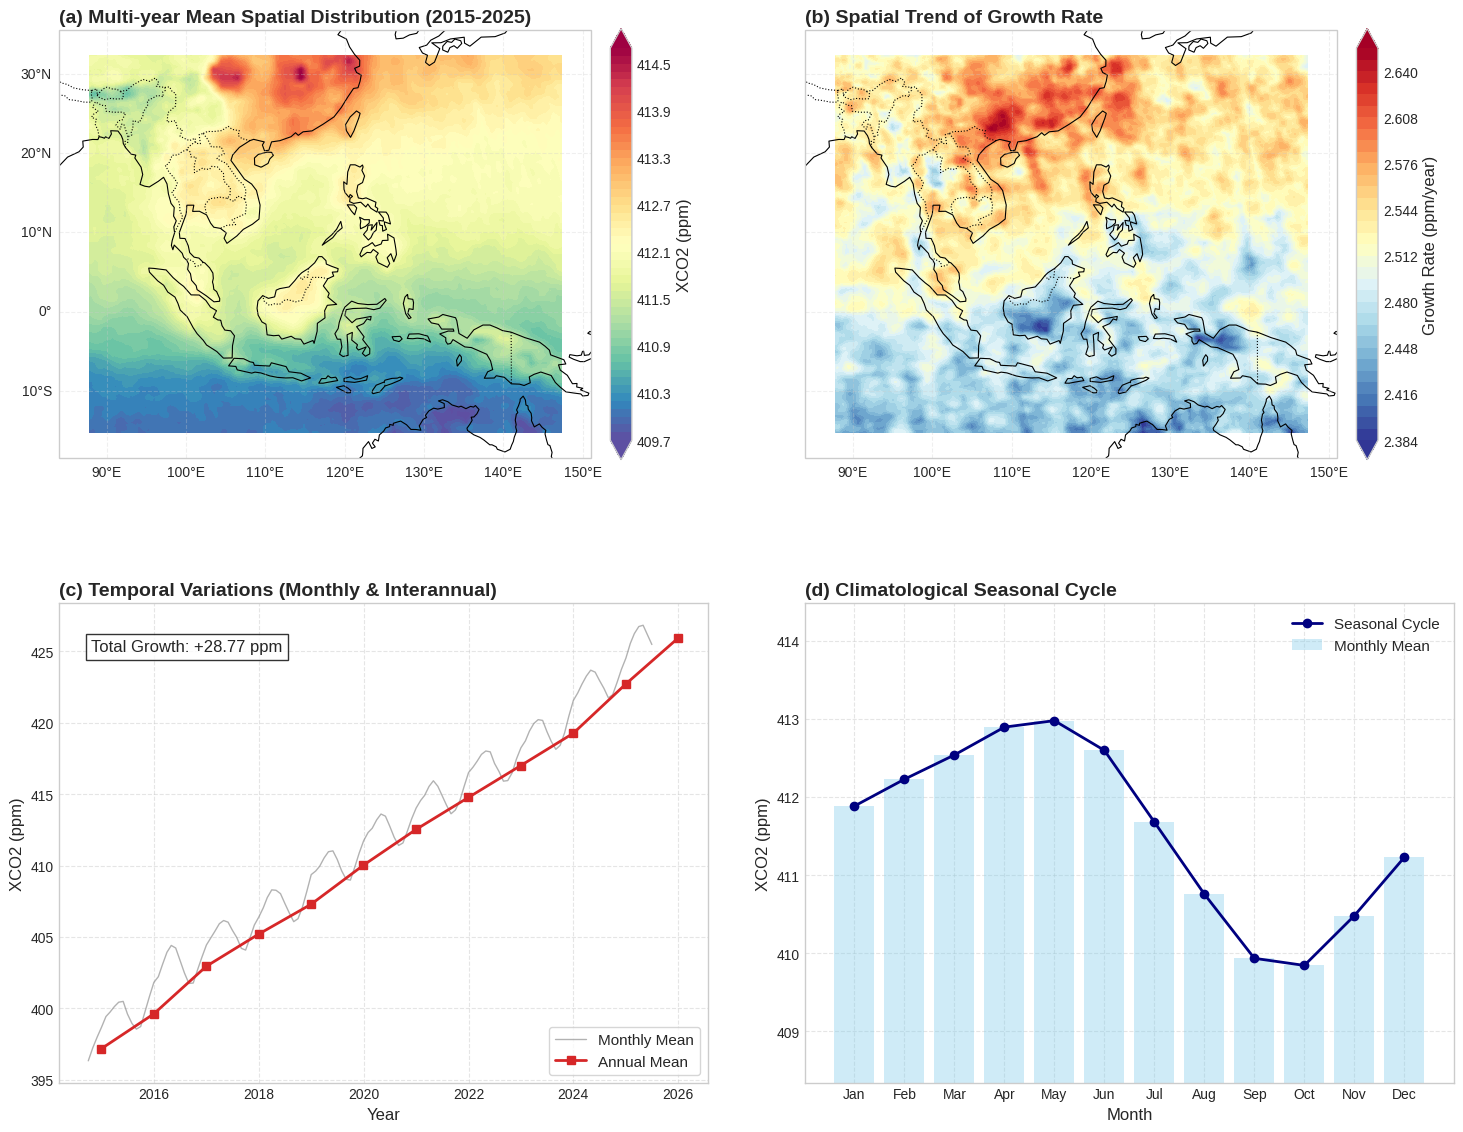

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.ticker as mticker
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False
stat_tag='oco2'
start_year=2015
end_year=2024
nc_path= step04_stk_fill_path / f"{stat_tag}_xco2_month_{start_year}_{end_year}_stk_SEA.nc"
ds = xr.open_dataset(nc_path)
var_name = list(ds.data_vars)[0]

name_dict = {}
for coord in ds.coords:
    c_low = coord.lower()
    if c_low in ['lat', 'latitude', 'lats']:
        name_dict[coord] = 'lat'
    elif c_low in ['lon', 'longitude', 'lons']:
        name_dict[coord] = 'lon'

if name_dict:
    ds = ds.rename(name_dict)

if 'lat' in ds.data_vars:
    ds = ds.set_coords(['lat', 'lon'])

var_name = list(ds.data_vars)[0]
da = ds[var_name]


da = ds[var_name]
if da.isnull().sum() > 0:
    da = da.interpolate_na(dim='lon', method='linear').interpolate_na(dim='lat', method='linear')

mean_map = da.mean(dim='time')
years_float = [pd.Timestamp(t).year + (pd.Timestamp(t).month-1)/12.0 for t in da.time.values]
da_trend = da.assign_coords(time=years_float)
poly = da_trend.polyfit(dim='time', deg=1)
slope_map = poly['polyfit_coefficients'].sel(degree=1) # Unit: ppm/year


ts_monthly = da.mean(dim=['lat', 'lon'])
ts_yearly = ts_monthly.resample(time='1Y').mean()

# 4. Seasonal Cycle (Line) - Detrended
# First calculate the linear trend
slope_t, intercept_t, _, _, _ = stats.linregress(np.arange(len(ts_monthly)), ts_monthly.values)
trend_line = intercept_t + slope_t * np.arange(len(ts_monthly))
ts_detrended = ts_monthly - trend_line
seasonal_cycle = ts_detrended.groupby('time.month').mean() + ts_monthly.mean() # Add back the mean to maintain the magnitude, or use Anomaly directly

# ================= 2. Plotting (2x2 Panel) =================
fig = plt.figure(figsize=(18, 14))
# Adjust subplot spacing
plt.subplots_adjust(wspace=0.15, hspace=0.25)

# ---------------- Subplot 1: Multi-year Mean Spatial Distribution (Map) ----------------
ax1 = fig.add_subplot(2, 2, 1, projection=ccrs.PlateCarree())
im1 = ax1.contourf(
    mean_map.lon, mean_map.lat, mean_map,
    transform=ccrs.PlateCarree(),
    cmap='Spectral_r', levels=60, extend='both'
)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax1.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.8)
# Color bar
cbar1 = plt.colorbar(im1, ax=ax1, shrink=0.9, pad=0.03)
cbar1.set_label('XCO2 (ppm)', fontsize=12)
ax1.set_title('(a) Multi-year Mean Spatial Distribution (2015-2025)', fontsize=14, loc='left', fontweight='bold')
# Lat/Lon labels
gl1 = ax1.gridlines(draw_labels=True, linestyle='--', alpha=0.3)
gl1.top_labels = False
gl1.right_labels = False

# ---------------- Subplot 2: Spatial Trend of Growth Rate (Map) ----------------
ax2 = fig.add_subplot(2, 2, 2, projection=ccrs.PlateCarree())
im2 = ax2.contourf(
    slope_map.lon, slope_map.lat, slope_map,
    transform=ccrs.PlateCarree(),
    cmap='RdYlBu_r', levels=40, extend='both' # Red=faster growth
)
ax2.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax2.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.8)
cbar2 = plt.colorbar(im2, ax=ax2, shrink=0.9, pad=0.03)
cbar2.set_label('Growth Rate (ppm/year)', fontsize=12)
ax2.set_title('(b) Spatial Trend of Growth Rate', fontsize=14, loc='left', fontweight='bold')
gl2 = ax2.gridlines(draw_labels=True, linestyle='--', alpha=0.3)
gl2.top_labels = False
gl2.right_labels = False
gl2.left_labels = False # Omit middle latitude labels

# ---------------- Subplot 3: Monthly and Annual Variation Curve (Time Series) ----------------
ax3 = fig.add_subplot(2, 2, 3)
# Plot monthly curve (thin gray line)
ax3.plot(ts_monthly.time, ts_monthly, color='gray', alpha=0.6, linewidth=1, label='Monthly Mean')
# Plot annual mean (red square line) - represents interannual variation
ax3.plot(ts_yearly.time, ts_yearly, 's-', color='#d62728', linewidth=2, label='Annual Mean')

# Calculate overall growth rate for annotation
total_growth = (ts_yearly[-1] - ts_yearly[0]).values
ax3.text(0.05, 0.9, f'Total Growth: +{total_growth:.2f} ppm', transform=ax3.transAxes,
         fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

ax3.set_ylabel('XCO2 (ppm)', fontsize=12)
ax3.set_xlabel('Year', fontsize=12)
ax3.legend(fontsize=11, frameon=True)
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.set_title('(c) Temporal Variations (Monthly & Interannual)', fontsize=14, loc='left', fontweight='bold')

# ---------------- Subplot 4: Multi-year Monthly Mean / Seasonality (Seasonal) ----------------
ax4 = fig.add_subplot(2, 2, 4)
months = np.arange(1, 13)
# Plot histogram background
ax4.bar(months, seasonal_cycle, color='skyblue', alpha=0.4, label='Monthly Mean')
# Plot smooth curve
ax4.plot(months, seasonal_cycle, 'o-', color='navy', linewidth=2, label='Seasonal Cycle')

# Set X-axis as month names
ax4.set_xticks(months)
ax4.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax4.set_ylabel('XCO2 (ppm)', fontsize=12)
ax4.set_xlabel('Month', fontsize=12)

y_min, y_max = seasonal_cycle.min(), seasonal_cycle.max()
ax4.set_ylim(y_min - 1.5, y_max + 1.5)

ax4.legend(fontsize=11)
ax4.grid(True, linestyle='--', alpha=0.5)
ax4.set_title('(d) Climatological Seasonal Cycle', fontsize=14, loc='left', fontweight='bold')

png_fn= doc_path / "Spatial Distribution of reconducted xco2 (2015-2045).png"
plt.savefig(png_fn, dpi=300, bbox_inches='tight')
plt.show()

#Independent Spatial Hold-out Validation

Methodology: Independent Spatial Validation To evaluate the ALSTK model's predictive performance in unsampled regions, a Spatial Hold-out approach was employed for out-of-sample accuracy validation: Data Partitioning: From a representative time-slice (e.g., March 2024), 10% of the original observation points were randomly selected as an independent validation set, while the remaining 90% served as the training set for model fitting. Masking Procedure: Validation pixels were masked (set to NaN) during the interpolation process to ensure a rigorous blind test, preventing any information leakage from the ground truth. Performance Metrics: The model's generalization capability was quantified by comparing masked observations with reconstructed values using the coefficient of determination ( R2 ), Root Mean Square Error (RMSE), and Bias.-- Figure Captions Figure 1.  XCO2  spatial reconstruction and technical validation for March 2024. (a) Original OCO-2 Observations: Initial satellite distribution showing prominent orbital gaps and cloud-induced data voids. (b) CAMS Background Field: Large-scale spatiotemporal prior trends utilized for the reconstruction process. (c) STK Reconstructed Product: Seamless, gap-filled  XCO2  field generated via the ALSTK algorithm. (d) Independent Validation: Scatter plot of the 10% hold-out samples; statistical metrics ( R2 , RMSE, and Bias) demonstrate the model's predictive robustness in unsampled regions.


🚀 Starting to process target: 2024-03
[02:27:47] 🎯 Found test target: 2024-03 (Time Index: 113)
[02:27:47] 🎲 Dataset split complete: 21887 valid observation points this month.
   -> For interpolation (90%): 19699 points
   -> For independent validation (10%): 2188 points (these points are completely hidden from the interpolation algorithm)
[02:27:47] Starting full-field STK reconstruction for 2024-03 (based on 90% data)...
[02:27:47] Month index 114/130 starting...
  Original observation points for this month: 19699
[02:30:32] Month index 114/130 Completed, coverage 100.0%
[02:30:32] Applying Gaussian smoothing to the final XCO2 field (sigma=0.6)...
[02:30:32] ✅ 2024-03 Reconstruction and smoothing complete! Time taken: 164.72 seconds
[02:30:32] Generating spatial distribution and independent validation accuracy plot...


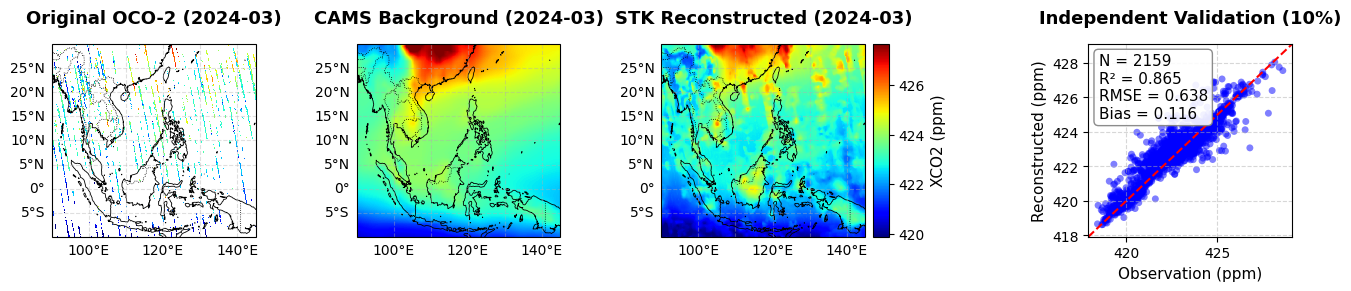

In [ ]:
import matplotlib.gridspec as gridspec
extent= [90,145,-10,30]
#date_list = [(2024, 3), (2024, 6), (2024, 9), (2024, 12)]
date_list = [(2024, 3)]
for target_year, target_month in date_list:
    print(f"\n{'='*60}")
    print(f"🚀 Starting to process target: {target_year}-{target_month:02d}")
    print(f"{'='*60}")

    target_indices = [
        i for i, d in enumerate(months_list)
        if d.year == target_year and d.month == target_month
    ]

    if not target_indices:
        print(f"⚠️ Skipping: No data found for {target_year}-{target_month:02d} in the dataset!")
        continue

    target_t_idx = target_indices[0]
    target_time = months_list[target_t_idx]

    print(f"[{time.strftime('%H:%M:%S')}] 🎯 Found test target: {target_time.strftime('%Y-%m')} (Time Index: {target_t_idx})")

    # ---------------------------------------------------------
    # 🌟 New Core Logic: 90% Training and 10% Validation Split
    # ---------------------------------------------------------
    # 1. Backup original residuals for the current month, for later restoration and extraction of true validation values
    original_res_this_month = res_array[target_t_idx].copy()
    valid_coords = np.argwhere(~np.isnan(original_res_this_month))
    n_valid = len(valid_coords)

    # 2. Randomly shuffle and split 90% / 10%
    np.random.seed(42)  # Fix random seed to ensure reproducible results for parameter tuning
    shuffle_idx = np.random.permutation(n_valid)
    n_val = int(n_valid * 0.1)  # 10% for independent validation

    val_idx = shuffle_idx[:n_val]
    train_idx = shuffle_idx[n_val:]

    val_coords = valid_coords[val_idx]
    train_coords = valid_coords[train_idx]

    print(f"[{time.strftime('%H:%M:%S')}] 🎲 Dataset split complete: {n_valid} valid observation points this month.")
    print(f"   -> For interpolation (90%): {len(train_idx)} points")
    print(f"   -> For independent validation (10%): {len(val_idx)} points (these points are completely hidden from the interpolation algorithm)")

    # 3. 'Hollow out' the 10% validation set in the global res_array
    # This way, krige_for_month will not use this 10% information when reading data
    for r, c in val_coords:
        res_array[target_t_idx, r, c] = np.nan


    # =========================================================
    # 6. Execute single-month reconstruction and final smoothing
    # =========================================================
    import matplotlib.gridspec as gridspec
    print(f"[{time.strftime('%H:%M:%S')}] Starting full-field STK reconstruction for {target_time.strftime('%Y-%m')} (based on 90% data)...")
    start_time = time.time()

    _, pred_month_target = krige_for_month(target_t_idx)

    # 🌟 After reconstruction, restore the 10% data to global variables to avoid affecting spatiotemporal interpolation for other months
    res_array[target_t_idx] = original_res_this_month

    # Residual + CAMS background field = Final preliminary XCO2
    cams_bg = ds_c["xco2"].values[target_t_idx].astype(np.float32)
    filled_xco2_raw = cams_bg + pred_month_target

    # Apply slight smoothing to the final result
    FINAL_SMOOTH_SIGMA = 0.6
    print(f"[{time.strftime('%H:%M:%S')}] Applying Gaussian smoothing to the final XCO2 field (sigma={FINAL_SMOOTH_SIGMA})...")
    filled_xco2 = gaussian_filter(filled_xco2_raw, sigma=FINAL_SMOOTH_SIGMA).astype(np.float32)

    cost_time = time.time() - start_time
    print(f"[{time.strftime('%H:%M:%S')}] ✅ {target_time.strftime('%Y-%m')} Reconstruction and smoothing complete! Time taken: {cost_time:.2f} seconds")


    # =========================================================
    # 7. Visualization: Original vs Background vs Reconstructed + 10% Independent Validation Scatter Plot
    # =========================================================
    print(f"[{time.strftime('%H:%M:%S')}] Generating spatial distribution and independent validation accuracy plot...")

    # Get the full original XCO2 for this month (including the 10% of points not involved in interpolation)
    original_xco2 = ds_o["xco2"].values[target_t_idx].astype(np.float32)

    fig = plt.figure(figsize=(16, 2.5))
    gs = gridspec.GridSpec(1, 7, figure=fig, width_ratios=[1, 0.2, 1, 0.2, 1, 0.8, 1])
    original_xco2 = ds_o["xco2"].values[target_t_idx].astype(np.float32)
    vmin = np.nanpercentile(cams_bg, 1)
    vmax = np.nanpercentile(cams_bg, 99)
    titles = [
        f"Original OCO-2 ({target_time.strftime('%Y-%m')})",
        f"CAMS Background ({target_time.strftime('%Y-%m')})",
        f"STK Reconstructed ({target_time.strftime('%Y-%m')})"
    ]
    data_list = [original_xco2, cams_bg, filled_xco2]
    map_axes = []
    for i, col_idx in enumerate([0, 2, 4]):
        ax = fig.add_subplot(gs[0, col_idx], projection=ccrs.PlateCarree())
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.set_aspect('auto', adjustable='box')
        ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
        ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.6)

        im = ax.pcolormesh(
            lon_g, lat_g, data_list[i],
            transform=ccrs.PlateCarree(),
            cmap='jet',
            vmin=vmin, vmax=vmax,
            shading='auto'
        )
        ax.set_title(titles[i], fontsize=13, pad=15, fontweight='bold')
        gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.4)
        gl.top_labels = gl.right_labels = False
        map_axes.append(ax)
    fig.canvas.draw()
    pos3 = map_axes[2].get_position()
    cax = fig.add_axes([pos3.x1 + 0.005, pos3.y0, 0.01, pos3.height])
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label('XCO2 (ppm)', fontsize=11)
    ax4 = fig.add_subplot(gs[0, 6])
    val_rows, val_cols = val_coords[:, 0], val_coords[:, 1]
    obs_vals = original_xco2[val_rows, val_cols]
    rec_vals = filled_xco2[val_rows, val_cols]
    valid_mask = ~np.isnan(obs_vals) & ~np.isnan(rec_vals)
    obs_vals, rec_vals = obs_vals[valid_mask], rec_vals[valid_mask]
    rmse = np.sqrt(np.mean((rec_vals - obs_vals)**2))
    bias = np.mean(rec_vals - obs_vals)
    corr = np.corrcoef(obs_vals, rec_vals)[0, 1]
    r2 = corr**2 if not np.isnan(corr) else 0
    ax4.scatter(obs_vals, rec_vals, c='blue', alpha=0.5, s=25, edgecolor='none')
    min_v, max_v = obs_vals.min() - 0.5, obs_vals.max() + 0.5
    ax4.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5)
    ax4.set_xlim([min_v, max_v])
    ax4.set_ylim([min_v, max_v])
    ax4.set_aspect('auto', adjustable='box')
    ax4.set_xlabel("Observation (ppm)", fontsize=11)
    ax4.set_ylabel("Reconstructed (ppm)", fontsize=11)
    ax4.set_title("Independent Validation (10%)", fontsize=13, pad=15, fontweight='bold')

    textstr = f'N = {len(obs_vals)}\nR² = {r2:.3f}\nRMSE = {rmse:.3f}\nBias = {bias:.3f}'
    ax4.text(0.05, 0.95, textstr, transform=ax4.transAxes, fontsize=11,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

    ax4.grid(True, linestyle='--', alpha=0.5)

    png_fn= doc_path / f"Validation_Hold-out_{target_time.strftime('%Y-%m')}"
    plt.savefig(png_fn, dpi=300, bbox_inches='tight')
    plt.show()